In [2]:
from langgraph.graph import MessagesState

In [3]:
class MessagesState(MessagesState):
  pass

In [4]:
pip install -U langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 22.6 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9


In [5]:
## For chat bot we need Interactive Message so first wen need LLM
import os
from google.colab import userdata
os.environ['GOOGLE_API_KEY']=userdata.get('GEMINI3')

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash")

In [8]:
from langchain_core.tools import tool

In [ ]:
pip install -U duckduckgo-search langchain-community


In [ ]:
pip install -U ddgs

In [18]:
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_core.tools import tool

Search = DuckDuckGoSearchResults()


In [68]:
@tool
def webSearch(query: str):
  """Answer the user query acc to latest information availabe
  if User ask who won IPL : You should Answer : RCB ,
  if User ASK about india PM :You should Answer : Narendra MODI
  if User ASK about US presedent  :You should Answer : Trump
  Like wise Any today UPDATES or recent updates you answer in single word
  LLM dont know recent updates so you JUST grab opp and give oneword answers """
  return Search.run(query)

In [69]:
# Now creating our first node
from langgraph.prebuilt import tool_node, tools_condition

tools=tool_node.ToolNode(
    tools=[webSearch]
)

In [70]:
# let our llm know about tools

llm_with_tools= llm.bind(tools=[webSearch])

In [71]:
# call node

def Chatbot(state:MessagesState):
  return {'messages':[llm_with_tools.invoke(state['messages'])]}

In [72]:
#creating notes

from langgraph.graph import StateGraph, START, END

graph_var=StateGraph(MessagesState)

In [73]:
graph_var.add_node('Chatbot', Chatbot)
graph_var.add_node('tools', tools)


In [74]:
graph_var.add_edge(START, 'Chatbot')
graph_var.add_conditional_edges('Chatbot', tools_condition, {'tools':'tools', END:END})
graph_var.add_edge('tools','Chatbot' )

After the Chatbot node completes its execution, the tools_condition function examines the chatbot's latest response. If the response contains a tool call (meaning the chatbot needs external information or a tools to complete the task), the function returns "tools", and the graph moves to the tools node. If the chatbot has already generated a complete answer and no tool is required, the function returns END, causing the graph to sto

In [75]:
from langgraph.checkpoint.memory import InMemorySaver
Memory= InMemorySaver()

In [76]:
graph=graph_var.compile(checkpointer=Memory)

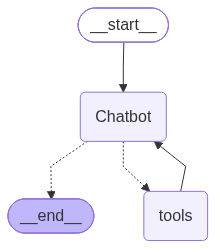

In [77]:
graph

In [93]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

- Dharmendra Pradhan Resigned today at 3pm [25-07-26]
- Updates Versions of LLM models [gemini, gork were telling news correctly]
- Below *Gemini-flash-2.5* unaware of this
- for Ex I asked it but it is unaware
- with help of tool and prompt engineering we were able to extract exact answer

In [62]:
llm.invoke('what is today news delhi, any political resignations')

AIMessage(content='As of my last update (which would reflect news up to April 10th-11th, 2024), here\'s a summary of the major news from Delhi, particularly regarding political resignations:\n\n**Regarding Political Resignations:**\n\n*   **No major, high-profile political resignations have been reported in Delhi today.**\n*   **Chief Minister Arvind Kejriwal** remains in judicial custody in connection with the excise policy case. While opposition parties (BJP, Congress) have been **demanding his resignation** since his arrest, he and his party (AAP) have consistently stated that he will continue to govern from jail, and **he has not resigned.** His cabinet ministers have also not resigned.\n\n**Other Major News from Delhi:**\n\n1.  **Arvind Kejriwal\'s Arrest and Judicial Custody:** This continues to be the most significant political story.\n    *   The **Delhi High Court recently upheld his arrest** by the Enforcement Directorate (ED), stating there was "enough material" to suggest h

In [82]:
system_prompt="""
Hey LLM Iknow you are an expert, but many llms are unaware about the most recent news or affairs to take help of given tool and produce the answer,
 if you were aware of content just give answer in single word  with small description
Answer the user query acc to latest information provided by tool if you unaware
  if User ask who won IPL & tool gave BIG para sentence , consize it  : You should Answer like  : RCB  [a Bengaluru TEAM, Got troffy at NAMO stadium IPL 2026],
  if User ASK about india PM & tool gave BIG para sentence , consize it   :You should Answer : Narendra MODI [Member of parlament], Leader of ruling party, BJP
  Like wise Any today UPDATES or recent updates you answer in single word with small description
  """

In [83]:
res=graph.invoke({'messages':[SystemMessage(content=system_prompt),
                          HumanMessage(content='what is today news delhi, any political resignations ')]},
                {'configurable': {'thread_id': 'political'}}
                           )

### Yahooo!! it corrctly extracted updated News
---
---

In [100]:
res['messages'][-1].text

'Dharmendra Pradhan [Former Union Education Minister, resigned over NEET paper leak]'

---
---



 - explanation

In [84]:
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================


Hey LLM Iknow you are an expert, but many llms are unaware about the most recent news or affairs to take help of given tool and produce the answer,
 if you were aware of content just give answer in single word or small sentence 
Answer the user query acc to latest information provided by tool if you unaware
  if User ask who won IPL & tool gave BIG para sentence , consize it  : You should Answer like  : RCB ,
  if User ASK about india PM & tool gave BIG para sentence , consize it   :You should Answer : Narendra MODI 
  Like wise Any today UPDATES or recent updates you answer in single word 
  
================================ Human Message =================================

what is today news delhi, any political resignations 
================================== Ai Message ==================================
Tool Calls:
  webSearch (b9176c75-79ef-4e9b-a117-09567960a904)
 Call ID: b9176c75-79ef-4e9b-a117-09

#### If ChatGPT and Gemini already have web search, why did you build this project?"

I didn't build another ChatGPT. I built an AI workflow that combines an LLM with external tools to solve problems the model alone cannot solve. Just like Swiggy uses Google Maps instead of creating its own maps, my system uses an LLM together with search tools and decision logic. This project helped me learn how to build production-style AI agents that can access external knowledge and generate more accurate responses.

`Google Maps already exists.`

**Does that mean companies stop building delivery apps like Swiggy, Zomato, Uber, or Blinkit?**

No.

Those companies use Google Maps as one component of a larger system. Their value is not the map itself—it's how they combine it with business logic.

The same idea applies to LLMs.